In [35]:
import pandas as pd
import numpy as np
import pickle
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import random
from scipy import stats # Sửa lỗi 'stats' is not defined
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold # Sửa lỗi 'KFold' is not defined

# Cấu hình giao diện và đồ thị
sns.set_theme(style="ticks") 
%matplotlib inline

In [41]:
%cd C:
medical = pd.read_csv(r"C:\DeepLearning\Lab_part_04\medical_care.csv")
print(medical.shape)
pd.set_option("display.max_columns", 50)
medical.head()

C:\Users\ADMIN\Untitled Folder
(35072, 29)


,UMARSTAT,UCUREMP,UCURNINS,USATMED,URELATE,REGION,STATE,HHID,FHOSP,FDENT,FEMER,FDOCT,UIMMSTAT,U_USBORN,UAGE,U_FTPT,U_WKSLY,U_HRSLY,U_USHRS,HEARNVAL,HOTHVAL,HRETVAL,HSSVAL,HWSVAL,UBRACE,GENDER,UEDUC3,CEYES,CHAIR
0,Never married,No,Yes,Very satisfied,2,Midwest,WI,55616128,No,0,0,0,US-born citizen,Yes,22,Full-time,52.0,40,40,0,0,0,0,0,White,Female,No HS diploma or GED,hazel,brown
1,Separated,Yes,No,Very satisfied,2,Midwest,WI,54704000,No,2,0,0,US-born citizen,Yes,30,Full-time,52.0,40,40,31468,5950,0,0,31468,White,Female,"HS diploma or GED, no bachelor's degree",blue,black
2,Married_live together,No,No,Very satisfied,5,Midwest,WI,57874272,No,0,1,0,US-born citizen,Yes,33,Part-time,52.0,30,30,24700,11340,0,4920,24700,White,Male,No HS diploma or GED,brown,brown
3,Divorced,No,Yes,Little dissatisfied,4,Midwest,WI,54106816,No,0,0,1,US-born citizen,Yes,41,Part-time,43.0,40,25,60000,39002,0,0,60000,Black,Female,No HS diploma or GED,brown,black
4,Never married,Yes,No,Very satisfied,0,Midwest,WI,54569152,No,2,0,0,US-born citizen,Yes,34,Full-time,52.0,40,40,55280,4200,0,0,55280,Black,Male,"HS diploma or GED, no bachelor's degree",brown,black


In [42]:
medical["UCURNINS"] = (medical.UCURNINS == "Yes").astype(int)

In [43]:
mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = medical,
                          family = sm.families.Binomial())
res = mod.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               UCURNINS   No. Observations:                35072
Model:                            GLM   Df Residuals:                    35036
Model Family:                Binomial   Df Model:                           35
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11126.
Date:                Fri, 06 Mar 2026   Deviance:                       22251.
Time:                        13:58:36   Pearson chi2:                 4.05e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1742
Covariance Type:            nonrobust                                         
=====================================================================================================================
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             0.9019      0.216      4.166      0.000       0.478       1.326
UMARSTAT[T.Married, do not live together]            -0.4264      0.166     -2.563      0.010      -0.752      -0.100
UMARSTAT[T.Married_live together]                    -0.8331      0.056    -14.774      0.000      -0.944      -0.723
UMARSTAT[T.Never married]                            -0.3337      0.064     -5.210      0.000      -0.459      -0.208
UMARSTAT[T.Partnership]                               0.3966      0.085      4.677      0.000       0.230       0.563
UMARSTAT[T.Separated]                                -0.0527      0.095     -0.553      0.580      -0.239       0.134
UMARSTAT[T.Unknown]                                   0.6720      0.388      1.732      0.083      -0.089       1.433
UMARSTAT[T.Widowed]                                  -0.1727      0.144     -1.197      0.231      -0.455       0.110
USATMED[T.Little satisfied]                          -0.4597      0.063     -7.324      0.000      -0.583      -0.337
USATMED[T.No opinion]                                 0.6913      0.098      7.025      0.000       0.498       0.884
USATMED[T.Very dissatisfied]                          0.5547      0.092      6.017      0.000       0.374       0.735
USATMED[T.Very satisfied]                            -0.7287      0.062    -11.668      0.000      -0.851      -0.606
REGION[T.Northeast]                                  -0.0486      0.057     -0.858      0.391      -0.159       0.062
REGION[T.South]                                       0.7221      0.047     15.439      0.000       0.630       0.814
REGION[T.West]                                        0.4020      0.049      8.143      0.000       0.305       0.499
FHOSP[T.Yes]                                         -0.2438      0.075     -3.254      0.001      -0.391      -0.097
UIMMSTAT[T.Foreign-born, non-citizen]                 0.7271      0.089      8.172      0.000       0.553       0.901
UIMMSTAT[T.US-born citizen]                          -0.5706      0.080     -7.114      0.000      -0.728      -0.413
U_FTPT[T.Part-time]                                   0.4966      0.058      8.526      0.000       0.382       0.611
UBRACE[T.Asian/Pacific Islander]                     -0.9828      0.161     -6.104      0.000      -1.298      -0.667
UBRACE[T.Black]                                      -0.4685      0.126     -3.710      0.000      -0.716      -0.221
UBRACE[T.White]                                      -0.5119      0.118     -4.338      0.000      -0.743      -0.281
UEDUC3[T.HS diploma or GED, no bachelor's degree]     0.8375      0.053     15.828      0.000       0.734       0.941
UEDUC3[T.No HS 

In [44]:
roc_auc_score(y_test, preds)

ValueError: Found input variables with inconsistent numbers of samples: [31565, 7014]

In [45]:
from sklearn.model_selection import train_test_split
import random

X_train, X_test, y_train, y_test = train_test_split(medical,
                                                    medical.UCURNINS,
                                                    test_size = 0.3,
                                                    random_state = random.randint(0, 1000))
print(X_train.shape, X_test.shape)
mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = X_train,
                          family = sm.families.Binomial())
res = mod.fit()
res.summary()
preds = res.predict(X_test)

roc_auc_score(y_test, preds)

(24550, 29) (10522, 29)


np.float64(0.8296587951044828)

In [46]:
scores = []

for k in range(100) :
    
    X_train, X_test, y_train, y_test = train_test_split(medical,
                                                        medical.UCURNINS,
                                                        stratify = medical.UCURNINS,
                                                        test_size = 0.3,
                                                        random_state = random.randint(0, 10000))
    # print(X_train.shape, X_test.shape)
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = X_train,
                              family = sm.families.Binomial())
    res = mod.fit()
    res.summary()
    preds = res.predict(X_test)
    scores.append(roc_auc_score(y_test, preds))
    # print(scores[-1])

In [8]:
medical.UCURNINS.value_counts()

UCURNINS
No     30006
Yes     5066
Name: count, dtype: int64

In [9]:
df = pd.DataFrame(data = scores, columns = ['scores'])
print(df.scores.describe())
print(f'Kurtosis \t %s' %round(df.scores.kurtosis(), 5)) # This one returns 'normalized' kurtosis (i.e. 0 instead of 3).
print(f'Skewness \t %s' %round(df.scores.skew(), 5))

count    100.000000
mean       0.173232
std        0.004551
min        0.159956
25%        0.169700
50%        0.173507
75%        0.176377
max        0.183509
Name: scores, dtype: float64
Kurtosis 	 -0.34093
Skewness 	 -0.15799


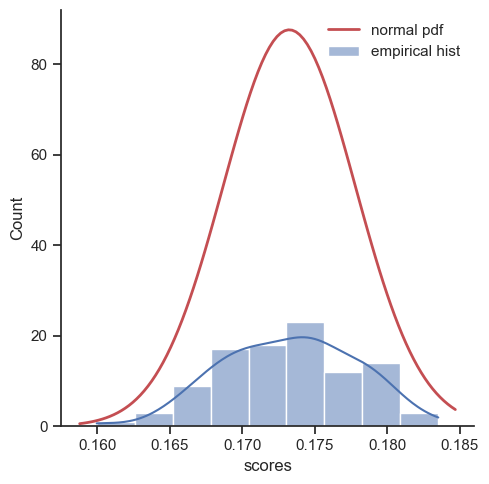

In [27]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.displot(data = df.scores, kde = True, label = 'empirical hist')
x0, x1 = ax.ax.get_xlim()
x_pdf = np.linspace(x0, x1, len(df))
y_pdf = stats.norm.pdf(x_pdf, df.scores.mean(), df.scores.std())
ax.ax.plot(x_pdf, y_pdf, 'r', lw = 2, label = 'normal pdf')
ax.ax.legend()

In [30]:
from scipy import stats 

alpha = 1e-3

k2, p = stats.normaltest(df.scores) # Kurtosis and skewness normality test.

if p < alpha :

    print('Kurtosis, Skewness test: The null hypothesis about normality can be rejected.')

else:

    print('Kurtosis, Skewness test: The null hypothesis about normality can not be rejected.')

# Kolmogorov Smirnov normality test.
ks = stats.kstest(df.scores, 'norm')

if ks[1] < alpha :

    print('Kolmogorov Smirnov test: The null hypothesis about normality can be rejected.')

else:

    print('Kolmogorov Smirnov test: The null hypothesis about normality can not be rejected.')

# Do you remember that @kstest function requires NORMALIZATION of sample?
ks = stats.kstest((df.scores - df.scores.mean()) / df.scores.std(), 'norm')

if ks[1] < alpha :

    print('Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can be rejected.')

else:

    print('Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can not be rejected.')

Kurtosis, Skewness test: The null hypothesis about normality can not be rejected.
Kolmogorov Smirnov test: The null hypothesis about normality can be rejected.
Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can not be rejected.


In [28]:
for k in range(1, 10) :
    
    X_train, X_test, y_train, y_test = train_test_split(medical,
                                                        medical.UCURNINS,
                                                        test_size = 0.1 * k,
                                                        random_state = 0)
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = X_train,
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(X_train)
    preds = res.predict(X_test)
    print("Train AUC:", round(roc_auc_score(y_train, predsTrain), 4), "Valid AUC:", round(roc_auc_score(y_test, preds), 4))

Train AUC: 0.1699 Valid AUC: 0.1804
Train AUC: 0.1695 Valid AUC: 0.1772
Train AUC: 0.1694 Valid AUC: 0.1758
Train AUC: 0.1707 Valid AUC: 0.1727
Train AUC: 0.1715 Valid AUC: 0.1722
Train AUC: 0.1673 Valid AUC: 0.1754
Train AUC: 0.1674 Valid AUC: 0.1749
Train AUC: 0.165 Valid AUC: 0.1773
Train AUC: 0.1486 Valid AUC: 0.1795


In [29]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    print("Train AUC:", round(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain), 4), "Valid AUC:",
          round(roc_auc_score(medical.iloc[test].UCURNINS, preds), 4))

Train AUC: 0.1713 Valid AUC: 0.1698
Train AUC: 0.1709 Valid AUC: 0.1707
Train AUC: 0.1707 Valid AUC: 0.1756
Train AUC: 0.1699 Valid AUC: 0.1804
Train AUC: 0.1691 Valid AUC: 0.1885
Train AUC: 0.1701 Valid AUC: 0.1797
Train AUC: 0.1703 Valid AUC: 0.1774
Train AUC: 0.1725 Valid AUC: 0.1582
Train AUC: 0.1711 Valid AUC: 0.1714
Train AUC: 0.1731 Valid AUC: 0.1511


In [15]:
from sklearn.model_selection import KFold
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())    
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    print("Train AUC:", round(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain), 4),
          "Valid AUC:", round(roc_auc_score(medical.iloc[test].UCURNINS, preds), 4))

Train AUC: 0.1711 Valid AUC: 0.1705
Train AUC: 0.171 Valid AUC: 0.1726
Train AUC: 0.1725 Valid AUC: 0.1667
Train AUC: 0.1692 Valid AUC: 0.1819
Train AUC: 0.17 Valid AUC: 0.1741


In [17]:
from sklearn.model_selection import KFold
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(medical.index.values):
        
        mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())          
        res = mod.fit()
        predsTrain = res.predict(medical.iloc[train])
        preds = res.predict(medical.iloc[test])
        trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
        valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.1709 Valid AUC: 0.1726
Train AUC: 0.1709 Valid AUC: 0.1724
Train AUC: 0.1709 Valid AUC: 0.1723
Train AUC: 0.1709 Valid AUC: 0.1725
Train AUC: 0.1709 Valid AUC: 0.1727
Train AUC: 0.1709 Valid AUC: 0.1728
Train AUC: 0.1709 Valid AUC: 0.1724
Train AUC: 0.1709 Valid AUC: 0.1722
Train AUC: 0.1709 Valid AUC: 0.1724
Train AUC: 0.1709 Valid AUC: 0.1725


In [18]:
from sklearn.model_selection import KFold
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(medical.index.values) :
        
        mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial()) 
        res = mod.fit()
        predsTrain = res.predict(medical.iloc[train])
        preds = res.predict(medical.iloc[test])
        trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
        valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.1708 Valid AUC: 0.1728
Train AUC: 0.1708 Valid AUC: 0.1723
Train AUC: 0.1708 Valid AUC: 0.1726
Train AUC: 0.1708 Valid AUC: 0.1728
Train AUC: 0.1708 Valid AUC: 0.1725
Train AUC: 0.1708 Valid AUC: 0.1723
Train AUC: 0.1708 Valid AUC: 0.1723
Train AUC: 0.1708 Valid AUC: 0.1726
Train AUC: 0.1708 Valid AUC: 0.1728
Train AUC: 0.1708 Valid AUC: 0.1726


In [31]:
from sklearn.model_selection import KFold
predList = []
indList = []
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = medical.iloc[train],
                          family = sm.families.Binomial()) 
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(medical.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
    valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.1708 Valid AUC: 0.1725


In [32]:
from sklearn.model_selection import StratifiedKFold

predList = []
indList = []
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values, medical.UCURNINS) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = medical.iloc[train],
                          family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(medical.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
    valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.1708 Valid AUC: 0.1725


In [33]:
predsSorted = pd.Series(sum(predList, []), index = sum(indList, [])).sort_index()
roc_auc_score(medical.UCURNINS.sort_index(), pd.Series(sum(predList, []), index = sum(indList, [])).sort_index())

np.float64(0.17260681960199617)

In [47]:
print(f'Overall percent of uninsured persons is %s' %round(medical.UCURNINS.sum() / medical.UCURNINS.count() * 100, 2))

Overall percent of uninsured persons is 14.44


In [48]:
print(f'Quality score for training set is %s' 
      %round(sum(medical.UCURNINS.iloc[train] == (predsTrain > 0.5) * 1) / len(train) * 100, 2))
print(f'Quality score for test set is %s' 
      %round(sum(medical.UCURNINS.iloc[test] == (preds > 0.5) * 1) / len(test) * 100, 2))

Quality score for training set is 12.83


ValueError: Can only compare identically-labeled Series objects